In [15]:
import time
import math
import json
import socket
from pynput import mouse

# --- CONFIGURAÇÃO DE COMUNICAÇÃO ---
IP_DESTINO = "127.0.0.1"
PORTA_DESTINO = 5005
sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)

#Variaveis
posicao_atual = (0, 0)
posicao_anterior = (0, 0)
distancia_acumulada = 0.0
historico_log = [] 

#PARAMETROS DE CALIBRACAO
SUAVIZACAO_SEGUNDOS = 3  
JANELA_CALIBRACAO_SEGUNDOS = 10  
PISO_MINIMO_PX = 30 # Valor minimo

janela_curta = []
janela_longa = [120.0] * JANELA_CALIBRACAO_SEGUNDOS

def ao_mover(x, y):
    global posicao_atual, posicao_anterior, distancia_acumulada
    posicao_atual = (x, y)
    dx = posicao_atual[0] - posicao_anterior[0]
    dy = posicao_atual[1] - posicao_anterior[1]
    distancia_acumulada += math.sqrt(dx**2 + dy**2)
    posicao_anterior = posicao_atual

listener = mouse.Listener(on_move=ao_mover)
listener.start()

print(f"Rastreando com Calibração Dinâmica (Janela: {JANELA_CALIBRACAO_SEGUNDOS}s).")

while True:
    time.sleep(1.0) 
    
    distancia_segundo_atual = distancia_acumulada
    distancia_acumulada = 0.0
    
    #ATUALIZA A JANELA CURTA (Ação Atual)
    janela_curta.append(distancia_segundo_atual)
    if len(janela_curta) > SUAVIZACAO_SEGUNDOS:
        janela_curta.pop(0)
        
    energia_media = sum(janela_curta) / len(janela_curta)
    
    # 2. ATUALIZA A JANELA LONGA (Calibração do Baseline)
    janela_longa.append(distancia_segundo_atual)
    if len(janela_longa) > JANELA_CALIBRACAO_SEGUNDOS:
        janela_longa.pop(0)
        
    media_calibracao = sum(janela_longa) / len(janela_longa)
    
    # Define a âncora dinâmica protegida pelo piso mínimo
    MOVIMENTO_NORMAL_PX = max(PISO_MINIMO_PX, media_calibracao)
    
    # 3. MAPEAMENTO DE ESTADOS (Agora referenciando a âncora ajustável)
    if energia_media < 10: 
        nivel = 1
    elif energia_media < (MOVIMENTO_NORMAL_PX * 0.5): 
        nivel = 2
    elif energia_media < (MOVIMENTO_NORMAL_PX * 1.5): 
        nivel = 3
    elif energia_media < (MOVIMENTO_NORMAL_PX * 2.5): 
        nivel = 4
    else: 
        nivel = 5
    
    # 4. CRIAR O INSTANTE E EXPORTAR
    instante_medido = {
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "nivel_agitacao": nivel,
        "energia_px_s": round(energia_media, 2),
        "baseline_atual_px": round(MOVIMENTO_NORMAL_PX, 2) # Exportando a âncora para auditoria
    }
    
    historico_log.append(instante_medido)
    
    with open("historico_agitacao.json", "w") as f:
        json.dump(historico_log, f, indent=4)
    
    mensagem_udp = json.dumps(instante_medido).encode('utf-8')
    sock.sendto(mensagem_udp, (IP_DESTINO, PORTA_DESTINO))
    
    # Print formatado para mostrar a variação do Baseline ao vivo
    print(f"Movimentação: {energia_media:04.0f} px/s | Baseline de Movimento: {MOVIMENTO_NORMAL_PX:04.0f} px/s | NÍVEL DE AGITAÇÃO: {nivel}")

Rastreando com Calibração Dinâmica (Janela: 10s).
Movimentação: 1727 px/s | Baseline de Movimento: 0281 px/s | NÍVEL DE AGITAÇÃO: 5
Movimentação: 0981 px/s | Baseline de Movimento: 0292 px/s | NÍVEL DE AGITAÇÃO: 5
Movimentação: 0881 px/s | Baseline de Movimento: 0348 px/s | NÍVEL DE AGITAÇÃO: 5
Movimentação: 0452 px/s | Baseline de Movimento: 0380 px/s | NÍVEL DE AGITAÇÃO: 3
Movimentação: 0378 px/s | Baseline de Movimento: 0370 px/s | NÍVEL DE AGITAÇÃO: 3
Movimentação: 0182 px/s | Baseline de Movimento: 0367 px/s | NÍVEL DE AGITAÇÃO: 2
Movimentação: 0089 px/s | Baseline de Movimento: 0371 px/s | NÍVEL DE AGITAÇÃO: 2
Movimentação: 0257 px/s | Baseline de Movimento: 0411 px/s | NÍVEL DE AGITAÇÃO: 3
Movimentação: 0281 px/s | Baseline de Movimento: 0415 px/s | NÍVEL DE AGITAÇÃO: 3
Movimentação: 0229 px/s | Baseline de Movimento: 0403 px/s | NÍVEL DE AGITAÇÃO: 3
Movimentação: 0081 px/s | Baseline de Movimento: 0238 px/s | NÍVEL DE AGITAÇÃO: 2
Movimentação: 0151 px/s | Baseline de Movimento:

KeyboardInterrupt: 

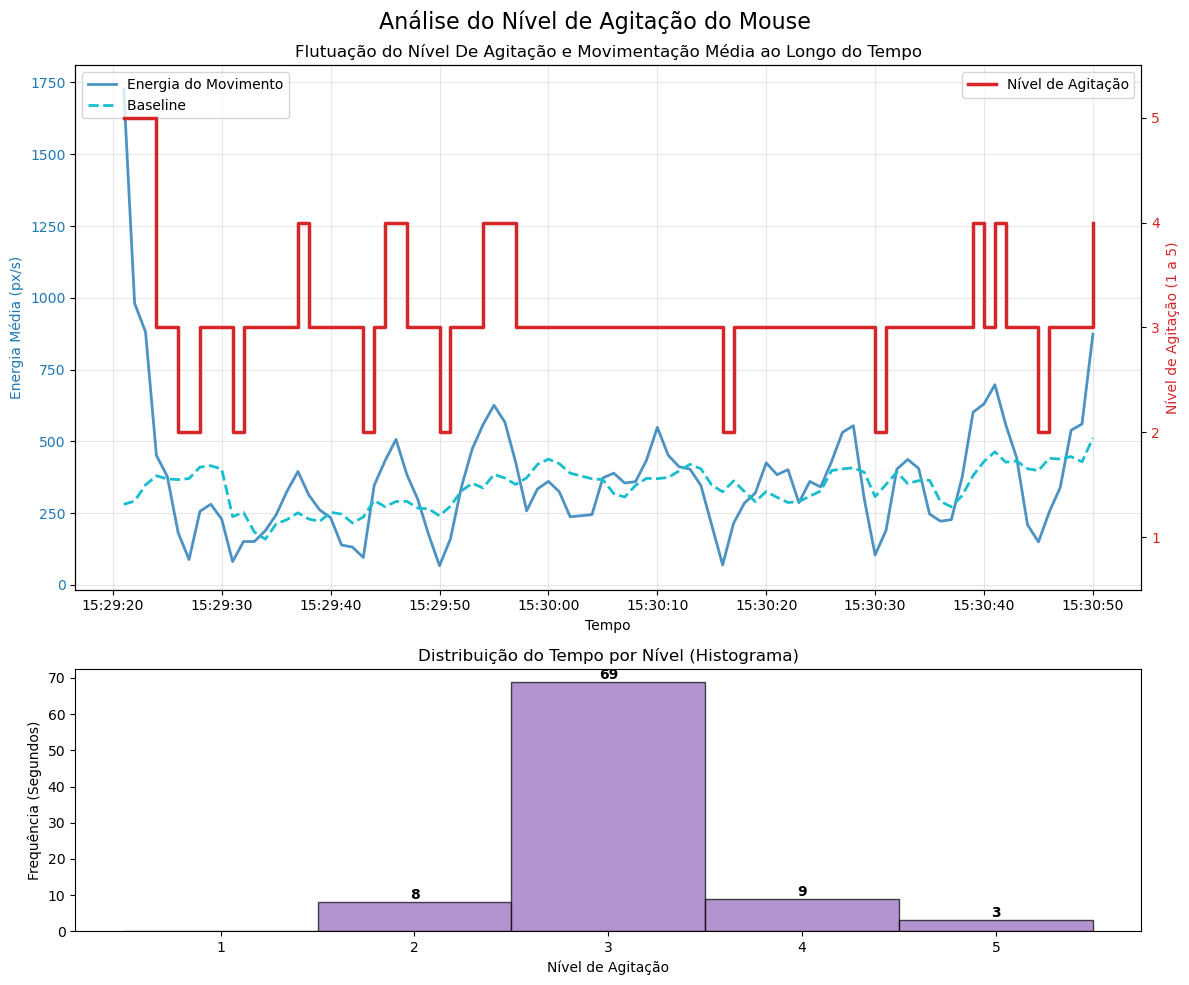

In [16]:
import json
import matplotlib.pyplot as plt
from datetime import datetime

def gerar_relatorio_grafico(arquivo_json="historico_agitacao.json"):
    # 1. CARREGAR OS DADOS
    try:
        with open(arquivo_json, "r") as f:
            dados = json.load(f)
    except FileNotFoundError:
        print(f"Erro: O arquivo {arquivo_json} não foi encontrado. Rode o coletor primeiro.")
        return

    if not dados:
        print("O arquivo JSON está vazio.")
        return

    # 2. EXTRAIR AS LISTAS PARA O PLOT
    # Converte as strings de tempo de volta para objetos datetime
    tempos = [datetime.strptime(d["timestamp"], "%Y-%m-%d %H:%M:%S") for d in dados]
    niveis = [d["nivel_agitacao"] for d in dados]
    energias = [d["energia_px_s"] for d in dados]
    baselines = [d.get("baseline_atual_px", 120) for d in dados] # Pega o baseline (ou 120 se for versão antiga)

    # 3. CONFIGURAR A FIGURA COM 2 ÁREAS (Subplots)
    # ax1 será o gráfico temporal, ax3 será o histograma
    fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})
    fig.suptitle('Análise do Nível de Agitação do Mouse', fontsize=16)

    # --- PLOT 1: TEMPO (ENERGIA x NÍVEL) ---
    color_energia = 'tab:blue'
    color_baseline = 'tab:cyan'
    
    # Plota a energia e o baseline no eixo esquerdo
    ax1.set_xlabel('Tempo')
    ax1.set_ylabel('Energia Média (px/s)', color=color_energia)
    ax1.plot(tempos, energias, label='Energia do Movimento', color=color_energia, alpha=0.8, linewidth=2)
    ax1.plot(tempos, baselines, label='Baseline ', color=color_baseline, linestyle='--', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color_energia)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')

    # Cria um segundo eixo Y compartilhando o mesmo eixo X para o Nível
    ax2 = ax1.twinx()
    color_nivel = 'tab:red'
    ax2.set_ylabel('Nível de Agitação (1 a 5)', color=color_nivel)
    # Usa 'step' para níveis, pois são estados discretos (degraus)
    ax2.step(tempos, niveis, label='Nível de Agitação', color=color_nivel, where='post', linewidth=2.5)
    ax2.set_ylim(0.5, 5.5) # Força o eixo ir de 1 a 5 com uma folga
    ax2.set_yticks([1, 2, 3, 4, 5])
    ax2.tick_params(axis='y', labelcolor=color_nivel)
    ax2.legend(loc='upper right')
    
    ax1.set_title('Flutuação do Nível De Agitação e Movimentação Média ao Longo do Tempo')

    # --- PLOT 2: HISTOGRAMA DE NÍVEIS ---
    ax3.set_title('Distribuição do Tempo por Nível (Histograma)')
    ax3.set_xlabel('Nível de Agitação')
    ax3.set_ylabel('Frequência (Segundos)')
    
    # Plota o histograma com 5 bins exatos alinhados nos níveis de 1 a 5
    bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
    ax3.hist(niveis, bins=bins, color='tab:purple', edgecolor='black', alpha=0.7)
    ax3.set_xticks([1, 2, 3, 4, 5])
    
    # Adiciona o número exato em cima de cada barra do histograma
    contagens = [niveis.count(i) for i in range(1, 6)]
    for i, count in enumerate(contagens):
        if count > 0:
            ax3.text(i + 1, count, str(count), ha='center', va='bottom', fontweight='bold')

    # 4. AJUSTAR O LAYOUT E MOSTRAR
    plt.tight_layout()
    plt.show()

# Executa a função
if __name__ == "__main__":
    gerar_relatorio_grafico()